In [1]:
import pandas as pd
from collections import Counter, defaultdict

import matplotlib.pyplot as plt


ARCHIVO = 'datos_asociados.csv'

In [2]:
datos = pd.read_csv(ARCHIVO, encoding='utf-8')
datos.shape

(21, 17)

In [8]:
#borrar la columna de marca temporal y sus datos
datos_limpios = datos.drop(columns=['Marca temporal'])
datos_limpios.head(5)

,Poner las iniciales de su nombre y apellidos,Edad,Sexo,Cantón donde vive,¿Cuál es su ingreso mensual aproximado?,¿A qué tipo de artesanía se dedica?,¿Cuánto tiempo tiene de emprender?,Cuántas personas trabajan con usted?,¿Con qué frecuencia asiste a ferias?,¿Con qué frecuencia asiste a capacitaciones?,¿Qué le impide participar en ferias? (puede marcar varias),¿Qué le impide participar en capacitaciones? (puede marcar varias),Marque cuáles de estas necesidades tiene cubiertas actualmente:,¿Considera que sus necesidades básicas están cubiertas?,¿Qué tipo de apoyo le gustaría recibir?,¿Le gustaría participar más en actividades si se mejoran las condiciones?
0,Melina Mongrut Flores,50 años,Femenino,Curridabat,Menos de ₡100.000,Bisutería - Joyería,Más de 3 años,Solo yo,Frecuentemente,Aveces,"Falta de dinero, Falta de espacios feriales, F...","Horario poco accesible, Problemas de transport...","Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender,Sí
1,M.E.B.R,57,Femenino,Alajuelita,Menos de ₡100.000,Gastronomía,Más de 3 años,Solo yo,Aveces,Aveces,"Falta de dinero, Problemas de transporte",Problemas de transporte,Acceso a agua potable,Parcialmente,Apoyo económico,Sí
2,NVAM,21 años,Femenino,Desamparados,Menos de ₡100.000,"Artículos de mujer, maquillaje, joyeria, cuida...",1 a 3 años,Solo yo,Frecuentemente,Aveces,Falta de espacios feriales,Horario poco accesible,"Alimentación diaria suficiente, Acceso a agua ...",Sí,Publicidad,Sí
3,Felicia Alvarez Méndez,48,Femenino,Vásquez de Coronado,₡100.000 – ₡300.000,Cosmética artesanal y decoraciones diversas,Más de 3 años,Mi familia,Frecuentemente,Frecuentemente,"Problemas de transporte, Falta de espacios fer...",Horario poco accesible,"Acceso a agua potable, Vivienda (techo seguro)...",Parcialmente,Apoyo económico,Sí
4,CPR,43,Femenino,Alajuelita,₡100.000 – ₡300.000,Tarjetería,1 a 3 años,Solo yo,Aveces,Casi nunca,"Problemas de transporte, Cuido de mis hijos. H...",Cuido de mis hijos. Choque de horarios educati...,"Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender con flexibilidad de horar...,No


In [7]:
datos_nombres = datos_limpios.rename(columns={
    "Poner las iniciales de su nombre y apellidos": "Nombre",
    "Edad": "Edad",
    "Sexo": "Sexo",
    "Cantón donde vive": "Canton",
    "¿Cuál es su ingreso mensual aproximado?": "Ingreso_Mensual",
    "¿A qué tipo de artesanía se dedica?": "Artesania",
    "¿Cuánto tiempo tiene de emprender?": "Tiempo_Emprender",
    "Cuántas personas trabajan con usted?": "Personas_Trabajan",
    "¿Con qué frecuencia asiste a ferias?": "Frecuencia_Ferias",
    "¿Con qué frecuencia asiste a capacitaciones?": "Frecuencia_Capacitaciones",
    "¿Qué le impide participar en ferias? (puede marcar varias)": "Impedimentos_Ferias",
    "¿Qué le impide participar en capacitaciones? (puede marcar varias)": "Impedimentos_Capacitaciones",
    "Marque cuáles de estas necesidades tiene cubiertas actualmente:": "Necesidades_Cubiertas",
    '¿Considera que sus necesidades básicas están cubiertas?': "Necesidades_Basicas",
    "¿Qué tipo de apoyo le gustaría recibir?": "Apoyo_Deseado",
    "¿Le gustaría participar más en actividades si se mejoran las condiciones?": "Participacion_Actividades"
})
datos_nombres.head(5)

,Nombre,Edad,Sexo,Canton,Ingreso_Mensual,Artesania,Tiempo_Emprender,Personas_Trabajan,Frecuencia_Ferias,Frecuencia_Capacitaciones,Impedimentos_Ferias,Impedimentos_Capacitaciones,Necesidades_Cubiertas,Necesidades_Basicas,Apoyo_Deseado,Participacion_Actividades
0,Melina Mongrut Flores,50 años,Femenino,Curridabat,Menos de ₡100.000,Bisutería - Joyería,Más de 3 años,Solo yo,Frecuentemente,Aveces,"Falta de dinero, Falta de espacios feriales, F...","Horario poco accesible, Problemas de transport...","Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender,Sí
1,M.E.B.R,57,Femenino,Alajuelita,Menos de ₡100.000,Gastronomía,Más de 3 años,Solo yo,Aveces,Aveces,"Falta de dinero, Problemas de transporte",Problemas de transporte,Acceso a agua potable,Parcialmente,Apoyo económico,Sí
2,NVAM,21 años,Femenino,Desamparados,Menos de ₡100.000,"Artículos de mujer, maquillaje, joyeria, cuida...",1 a 3 años,Solo yo,Frecuentemente,Aveces,Falta de espacios feriales,Horario poco accesible,"Alimentación diaria suficiente, Acceso a agua ...",Sí,Publicidad,Sí
3,Felicia Alvarez Méndez,48,Femenino,Vásquez de Coronado,₡100.000 – ₡300.000,Cosmética artesanal y decoraciones diversas,Más de 3 años,Mi familia,Frecuentemente,Frecuentemente,"Problemas de transporte, Falta de espacios fer...",Horario poco accesible,"Acceso a agua potable, Vivienda (techo seguro)...",Parcialmente,Apoyo económico,Sí
4,CPR,43,Femenino,Alajuelita,₡100.000 – ₡300.000,Tarjetería,1 a 3 años,Solo yo,Aveces,Casi nunca,"Problemas de transporte, Cuido de mis hijos. H...",Cuido de mis hijos. Choque de horarios educati...,"Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender con flexibilidad de horar...,No


In [5]:
#print nombre y edad de cada persona
for index, row in datos_nombres.iterrows():
    print(f"Nombre: {row['Nombre']}, Edad: {row['Edad']}")

Nombre: Melina Mongrut Flores , Edad: 50 años 
Nombre: M.E.B.R, Edad: 57
Nombre: NVAM, Edad: 21 años 
Nombre: Felicia Alvarez Méndez , Edad: 48
Nombre: CPR, Edad: 43
Nombre: AIZJ, Edad: 61
Nombre: Doriam Molina García , Edad: 39
Nombre: BA, Edad: 55
Nombre: JGS, Edad: 38
Nombre: ATM, Edad: 34
Nombre: ATM, Edad: 34
Nombre: I L Aguirre Guadamuz , Edad: 60
Nombre: Vanessa Blanco Cascante , Edad: 35
Nombre: E . Arce, Edad: 41
Nombre: Angie BG, Edad: 42
Nombre: Yency Aguilar Chavarria , Edad: 52
Nombre: VGMC, Edad: 37 años
Nombre: LGAJ, Edad: 53
Nombre: Leila Ureña Bolaños , Edad: 59
Nombre: ACE, Edad: 46
Nombre: Lorena Castro , Edad: 63


Counter({'Menos de ₡100.000': 12, '₡100.000 – ₡300.000': 7, 'Más de ₡600.000': 2})


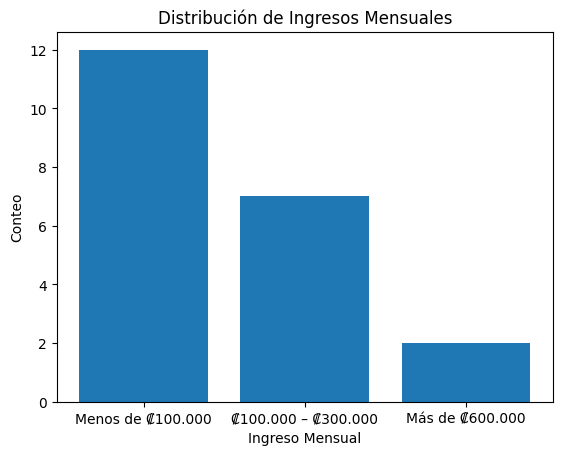

In [16]:
#contar cuantas personas hay por ganancioas mensual
conteo_ingresos = Counter(datos_nombres['Ingreso_Mensual'])
print(conteo_ingresos)
#un grafco de barras con los ingresos mensuales y su conteo usando matplotlib
#agrega etiquetas a los ejes y un titulo
plt.bar(conteo_ingresos.keys(), conteo_ingresos.values())
plt.xlabel('Ingreso Mensual')
plt.ylabel('Conteo')
plt.title('Distribución de Ingresos Mensuales')
plt.show()